<a href="https://colab.research.google.com/github/nishasn10/Aiml_project/blob/main/Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (6178, 3)

First 5 Rows:
   Unnamed: 0               comment  sentiment
0           0          what happens        0.0
1           1                    😞😞       -1.0
2           2           ان شاء الله        0.0
3           3  بالتوفيق ان شاء الله        1.0
4           4   الحمدلله على كل حال        1.0

Missing Values:
comment      0
sentiment    1
dtype: int64

Training Data: (4941,)
Testing Data: (1236,)

TF-IDF Training Shape:
(4941, 10000)

NAIVE BAYES RESULTS
Accuracy: 73.06%

Confusion Matrix:
[[429  75   1]
 [158 429   2]
 [ 33  64  45]]

Classification Report:
              precision    recall  f1-score   support

        -1.0       0.69      0.85      0.76       505
         0.0       0.76      0.73      0.74       589
         1.0       0.94      0.32      0.47       142

    accuracy                           0.73      1236
   macro avg       0.79      0.63      0.66      1236
weighted avg       0.75      0.73      0.72      1236



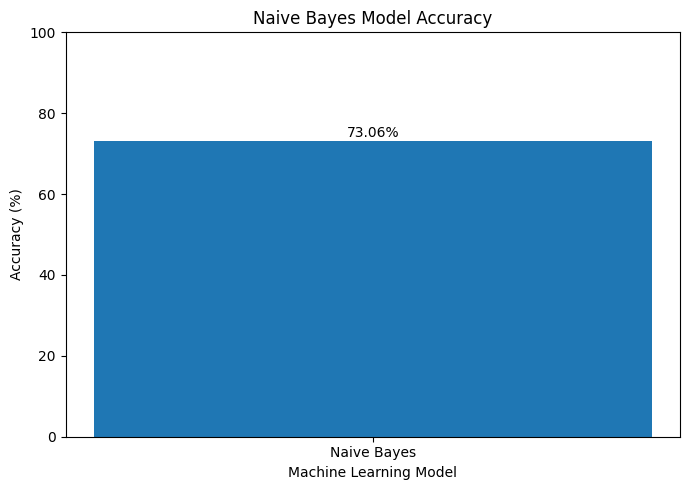

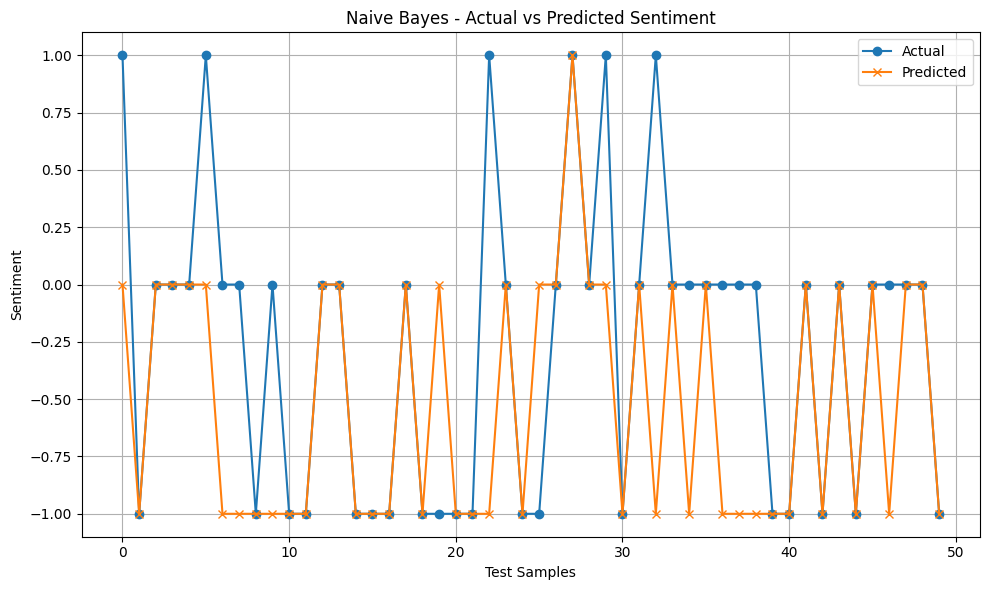

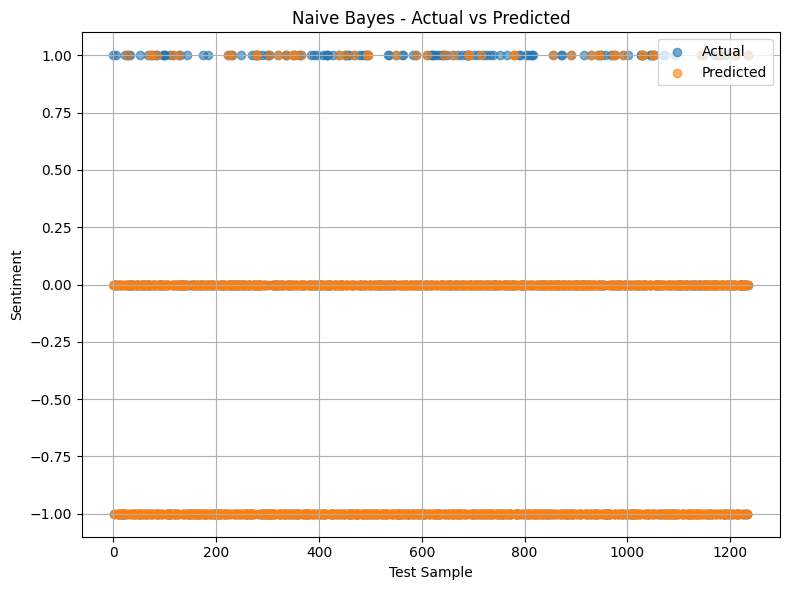

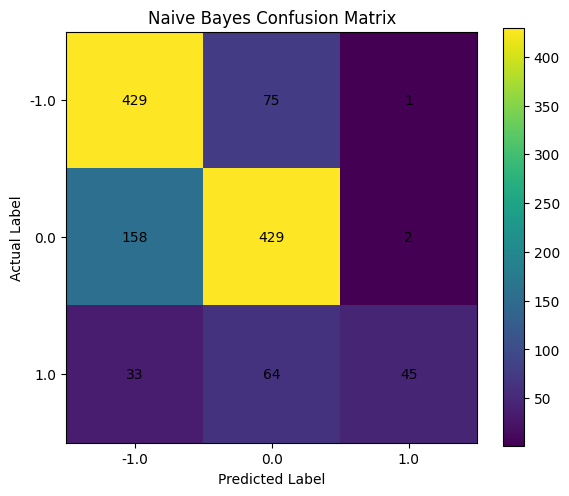

In [7]:
# ============================================================
# NAIVE BAYES - SENTIMENT ANALYSIS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("Sentiment_Anaysis.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# 2. REMOVE UNNECESSARY COLUMN
# ============================================================

if "Unnamed: 0" in df.columns:
    df = df.drop("Unnamed: 0", axis=1)


# ============================================================
# 3. CHECK MISSING VALUES
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# 4. REMOVE MISSING VALUES
# ============================================================

df = df.dropna(
    subset=["comment", "sentiment"]
)


# ============================================================
# 5. CONVERT COMMENT TO STRING
# ============================================================

df["comment"] = df["comment"].astype(str)


# ============================================================
# 6. SEPARATE FEATURES AND TARGET
# ============================================================

X = df["comment"]

y = df["sentiment"]


# ============================================================
# 7. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# ============================================================
# 8. TF-IDF VECTORIZATION
# ============================================================

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(
    X_train
)

X_test_tfidf = vectorizer.transform(
    X_test
)

print("\nTF-IDF Training Shape:")
print(X_train_tfidf.shape)


# ============================================================
# 9. CREATE NAIVE BAYES MODEL
# ============================================================

model = MultinomialNB()


# ============================================================
# 10. TRAIN MODEL
# ============================================================

model.fit(
    X_train_tfidf,
    y_train
)


# ============================================================
# 11. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(
    X_test_tfidf
)


# ============================================================
# 12. CALCULATE ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n========================================")
print("NAIVE BAYES RESULTS")
print("========================================")

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)


# ============================================================
# 13. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ============================================================
# 14. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)


# ============================================================
# 15. BAR CHART - ACCURACY
# ============================================================

plt.figure(figsize=(7, 5))

plt.bar(
    ["Naive Bayes"],
    [accuracy * 100]
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")

plt.title(
    "Naive Bayes Model Accuracy"
)

plt.ylim(0, 100)

plt.text(
    0,
    accuracy * 100 + 1,
    f"{accuracy * 100:.2f}%",
    ha="center"
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. LINE CHART - ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    y_test.values[:50],
    marker="o",
    label="Actual"
)

plt.plot(
    y_pred[:50],
    marker="x",
    label="Predicted"
)

plt.xlabel("Test Samples")
plt.ylabel("Sentiment")

plt.title(
    "Naive Bayes - Actual vs Predicted Sentiment"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 17. SCATTER CHART
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    range(len(y_test)),
    y_test,
    label="Actual",
    alpha=0.6
)

plt.scatter(
    range(len(y_pred)),
    y_pred,
    label="Predicted",
    alpha=0.6
)

plt.xlabel("Test Sample")
plt.ylabel("Sentiment")

plt.title(
    "Naive Bayes - Actual vs Predicted"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 18. CONFUSION MATRIX HEATMAP
# ============================================================

plt.figure(figsize=(6, 5))

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "Naive Bayes Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.colorbar()

plt.xticks(
    range(len(model.classes_)),
    model.classes_
)

plt.yticks(
    range(len(model.classes_)),
    model.classes_
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.show()